#📌 Extracão

In [1]:
import pandas as pd
import requests

# Extração dos dados da API
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

data = requests.get(url).json()
df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [4]:
# baixar o dicionário de dados do repositório
url_dict = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_dicionario.md"

# fazer a requisição do arquivo markdown
response_dict = requests.get(url_dict)
response_dict.raise_for_status()  # garante que a requisição foi bem-sucedida

# armazenar o conteúdo do arquivo em texto
dict_md = response_dict.text

# visualizar apenas o início do dicionário para conferência
print(dict_md[:500])

#### Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa 
* `gender`: gênero (masculino e feminino) 
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos 
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico 
* `MultipleLin


In [7]:
# verificar as colunas do dataframe e seus tipos de dados
print(df.dtypes)

# visualizar uma linha para entender a estrutura dos dados
print(df.iloc[0])


customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object
customerID                     0002-ORFBO
Churn                                  No
customer.gender                    Female
customer.SeniorCitizen                  0
customer.Partner                      Yes

In [8]:
# normalizar os dados json para garantir que estruturas aninhadas virem colunas
df = pd.json_normalize(data, sep='.')

# verificar as colunas geradas e o tamanho do dataframe
print(df.columns.tolist())
print(df.shape)

['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']
(7267, 21)


In [11]:
# verificar valores ausentes e vazios
print(df.isnull().sum())
print((df == '').sum())

# verificar duplicatas
print(df.duplicated().sum())

# verificar tipos de dados
print(df.dtypes)

# analisar valores únicos das principais colunas categóricas
colunas_categoricas = [
    'Churn',
    'customer.gender',
    'customer.SeniorCitizen',
    'customer.Partner',
    'customer.Dependents',
    'phone.PhoneService',
    'internet.InternetService',
    'account.Contract',
    'account.PaymentMethod'
]

for coluna in colunas_categoricas:
    print(coluna, df[coluna].unique())

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64
customerID                     0
Churn                        224
customer.gender                0
customer.SeniorCitizen         0
customer.Partner               0
customer.Dependents            0
customer.tenure                0
phone.PhoneService             0
phone.MultipleLines            0
internet.InternetService       0
intern

In [12]:
# remover registros sem informação de churn
df = df[df['Churn'].notnull()]
df = df[df['Churn'] != '']

# remover possíveis linhas duplicadas
df = df.drop_duplicates()

# padronizar formatação das colunas categóricas (remover espaços e normalizar texto)
colunas_categoricas = [
    'Churn',
    'customer.gender',
    'customer.Partner',
    'customer.Dependents',
    'phone.PhoneService',
    'phone.MultipleLines',
    'internet.InternetService',
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies',
    'account.Contract',
    'account.PaperlessBilling',
    'account.PaymentMethod'
]

for col in colunas_categoricas:
    df[col] = df[col].astype(str).str.strip().str.title()

# converter colunas numéricas
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# preencher valores ausentes em total charges
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# garantir tipos numéricos corretos
df['customer.tenure'] = df['customer.tenure'].astype(int)
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].astype(int)

# visualizar resultado após limpeza
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,Dsl,...,Yes,No,Yes,Yes,No,One Year,Yes,Mailed Check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,Dsl,...,No,No,No,No,Yes,Month-To-Month,No,Mailed Check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber Optic,...,No,Yes,No,No,No,Month-To-Month,Yes,Electronic Check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber Optic,...,Yes,Yes,No,Yes,Yes,Month-To-Month,Yes,Electronic Check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber Optic,...,No,No,Yes,Yes,No,Month-To-Month,Yes,Mailed Check,83.9,267.40


In [13]:
# criar coluna de gasto diário a partir do valor mensal
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30

# visualizar amostra para conferir o cálculo
df[['account.Charges.Monthly', 'Contas_Diarias']].head()


,account.Charges.Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


#📊 Carga e análise

In [14]:
# visualizar estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer.SeniorCitizen,7043.0,0.162147,0.368612,0.000000,0.000000,0.000,0.000,1.000000
customer.tenure,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000,72.000000
account.Charges.Monthly,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850,118.750000
account.Charges.Total,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550,3786.600,8684.800000
Contas_Diarias,7043.0,2.158723,1.003002,0.608333,1.183333,2.345,2.995,3.958333


In [15]:
# calcular medianas das variáveis numéricas
df.median(numeric_only=True)

,0
customer.SeniorCitizen,0.000
customer.tenure,29.000
account.Charges.Monthly,70.350
account.Charges.Total,1394.550
Contas_Diarias,2.345


In [ ]:
# contar clientes por status de churn
df['Churn'].value_counts()

📌 Clientes por status de evasão (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [16]:
# calcular média de gasto mensal por tipo de contrato
df.groupby('account.Contract')['account.Charges.Monthly'].mean()

,account.Charges.Monthly
account.Contract,
Month-To-Month,66.398490
One Year,65.048608
Two Year,60.770413


In [17]:
# calcular desvio padrão do gasto diário
df['Contas_Diarias'].std()

1.0030015699226154

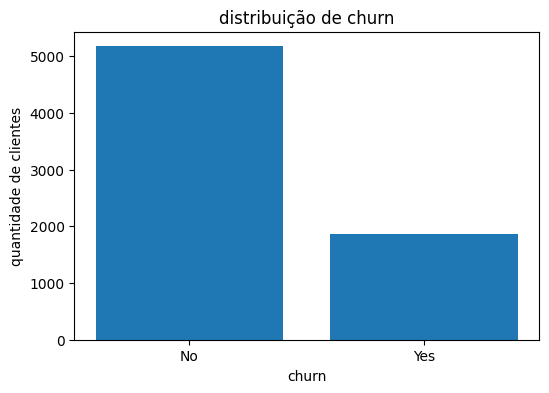

In [20]:
import matplotlib.pyplot as plt

# contar clientes por status de churn
counts = df['Churn'].value_counts()

# gráfico de distribuição de churn
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title('distribuição de churn')
plt.xlabel('churn')
plt.ylabel('quantidade de clientes')
plt.show()

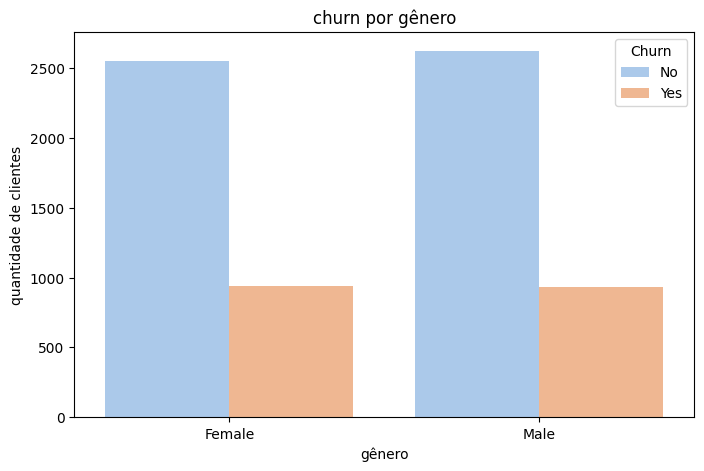

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# distribuição de churn por gênero
plt.figure(figsize=(8,5))
sns.countplot(x='customer.gender', hue='Churn', data=df, palette='pastel')

plt.xlabel('gênero')
plt.ylabel('quantidade de clientes')
plt.title('churn por gênero')

plt.show()

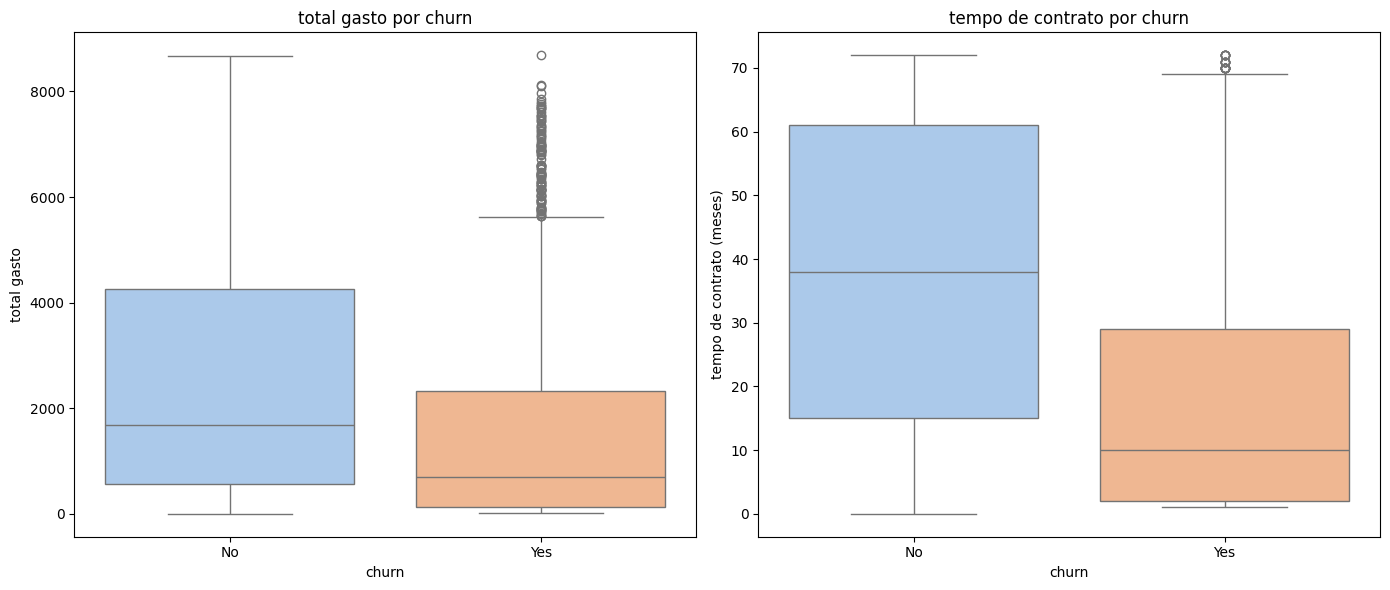

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# distribuição do total gasto por churn
sns.boxplot(
    x='Churn',
    y='account.Charges.Total',
    hue='Churn',
    data=df,
    palette='pastel',
    ax=axes[0],
    legend=False
)
axes[0].set_title('total gasto por churn')
axes[0].set_xlabel('churn')
axes[0].set_ylabel('total gasto')

# distribuição do tempo de contrato por churn
sns.boxplot(
    x='Churn',
    y='customer.tenure',
    hue='Churn',
    data=df,
    palette='pastel',
    ax=axes[1],
    legend=False
)
axes[1].set_title('tempo de contrato por churn')
axes[1].set_xlabel('churn')
axes[1].set_ylabel('tempo de contrato (meses)')

plt.tight_layout()
plt.show()

#📄Relatorio Final

**análise de evasão de clientes (churn)**

1 - introdução

A evasão de clientes (churn) é um dos principais desafios enfrentados por empresas que oferecem serviços recorrentes. Quando um cliente cancela o serviço, a empresa perde receita e precisa investir mais recursos para adquirir novos clientes. Por isso, compreender os fatores que influenciam o cancelamento é fundamental para desenvolver estratégias de retenção.

Neste trabalho foi realizada uma análise exploratória de dados (EDA) com o objetivo de identificar padrões associados à evasão de clientes. A base de dados utilizada contém informações demográficas, contratuais e financeiras dos clientes da empresa.

2 - limpeza e tratamento de dados

Durante o processo de preparação dos dados foram executadas algumas etapas importantes de tratamento e organização das informações.

Inicialmente foi realizada a importação dos dados e a visualização das colunas disponíveis no conjunto de dados. Em seguida foram analisados os nomes das variáveis, que estavam organizadas em estruturas como "customer", "account", "internet" e "phone".

Também foram realizadas verificações para identificar valores ausentes ou inconsistentes. Sempre que necessário, foram feitos ajustes para garantir que as colunas estivessem no formato adequado para análise.

Além disso, as variáveis foram classificadas entre categóricas e numéricas, o que permitiu escolher os tipos de visualização mais adequados durante a análise exploratória.

3 - análise exploratória de dados (eda)

3.1 - distribuição geral de churn

Inicialmente foi analisada a distribuição geral da variável churn, identificando a proporção de clientes que cancelaram o serviço em comparação com aqueles que permaneceram na empresa. Essa etapa é importante para entender a dimensão do problema de evasão.

3.2 - distribuição por variáveis categóricas

Foram utilizados gráficos para analisar como o churn se distribui entre diferentes categorias de clientes, como gênero, tipo de contrato e método de pagamento. Essas visualizações ajudam a identificar possíveis perfis de clientes com maior tendência ao cancelamento.

3.3 - distribuição por variáveis numéricas

Também foram utilizadas visualizações como boxplots para comparar o comportamento de algumas variáveis numéricas entre clientes que cancelaram e clientes que permaneceram. As principais variáveis analisadas foram o total gasto pelo cliente e o tempo de permanência na empresa.

Os resultados indicam que clientes que cancelam tendem a apresentar menor tempo de contrato e menor valor total gasto ao longo do relacionamento com a empresa.

4 - conclusões e insights

A análise exploratória permitiu identificar alguns padrões importantes relacionados à evasão de clientes.

Clientes com menor tempo de contrato apresentam maior probabilidade de cancelar o serviço. Isso sugere que muitos cancelamentos ocorrem nos primeiros meses de relacionamento com a empresa.

Também foi observado que clientes que cancelam tendem a apresentar menor gasto total acumulado, indicando um menor nível de engajamento com os serviços oferecidos.

Por outro lado, variáveis demográficas como gênero não apresentaram diferenças relevantes entre clientes que cancelaram e aqueles que permaneceram.

5 - recomendações

Com base nos resultados da análise, algumas ações podem ser consideradas para reduzir a taxa de evasão de clientes.

Uma possível estratégia é implementar campanhas de fidelização voltadas para clientes com pouco tempo de contrato, incentivando a permanência nos primeiros meses.

Também pode ser interessante criar benefícios progressivos para clientes que permanecem por mais tempo na empresa, aumentando o valor percebido do serviço.

Outra recomendação é analisar com mais profundidade os tipos de contrato e métodos de pagamento associados a maiores taxas de churn, buscando identificar oportunidades de melhoria.

Por fim, os dados analisados podem servir como base para o desenvolvimento de modelos preditivos de churn utilizando técnicas de machine learning, permitindo identificar clientes com maior risco de cancelamento e agir de forma preventiva.

6 - considerações finais

A análise exploratória realizada permitiu compreender melhor o comportamento dos clientes e identificar fatores associados à evasão. Embora a análise tenha caráter inicial, os resultados já apontam direções importantes para estratégias de retenção.

Estudos futuros podem aprofundar a investigação utilizando modelos estatísticos ou algoritmos de machine learning para prever churn com maior precisão. Dessa forma, a empresa poderá atuar de maneira mais estratégica, antecipando cancelamentos e fortalecendo o relacionamento com seus clientes.

*análise revisada com inteligência artificial*